# Algorithm Speed & Efficiency Visualizations

Comprehensive visual analysis of all cryptographic algorithms tested on ESP32

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Your benchmark data
serial_output = """
ets Jul 29 2019 12:21:46

rst:0x1 (POWERON_RESET),boot:0x13 (SPI_FAST_FLASH_BOOT)
configsip: 0, SPIWP:0xee
clk_drv:0x00,q_drv:0x00,d_drv:0x00,cs0_drv:0x00,hd_drv:0x00,wp_drv:0x00
mode:DIO, clock div:1
load:0x3fff0030,len:4888
load:0x40078000,len:16456
load:0x40080400,len:4
load:0x40080404,len:3476
entry 0x400805b4
{"note":"ESP32 Crypto Benchmark starting"}
{"alg":"AES-128-CBC","size":16,"iterations":200,"enc_us_total":2995,"dec_us_total":3096,"enc_bps":1068447.412354,"dec_bps":1033591.731266,"heap_before":268064,"heap_after":268064,"stack_hwm_before":6140,"stack_hwm_after":6140}
{"alg":"AES-256-GCM","size":16,"iterations":200,"enc_us_total":7799,"dec_us_total":8028,"enc_bps":410309.013976,"dec_bps":398604.882910,"heap_before":268064,"heap_after":268064,"stack_hwm_before":6140,"stack_hwm_after":6140}
{"alg":"RSA-2048-sign","msg_size":16,"iterations":50,"sign_us_total":10856638,"verify_us_total":50072,"sign_bps":73.687637,"verify_bps":15976.993130,"heap_before":266668,"heap_after":264776,"stack_hwm_before":6140,"stack_hwm_after":6032}
{"alg":"AES-128-CBC","size":128,"iterations":200,"enc_us_total":5624,"dec_us_total":6203,"enc_bps":4551920.341394,"dec_bps":4127035.305497,"heap_before":267492,"heap_after":267492,"stack_hwm_before":6032,"stack_hwm_after":6032}
{"alg":"AES-256-GCM","size":128,"iterations":200,"enc_us_total":20090,"dec_us_total":20362,"enc_bps":1274265.803883,"dec_bps":1257243.885669,"heap_before":267492,"heap_after":267492,"stack_hwm_before":6032,"stack_hwm_after":6032}
{"alg":"RSA-2048-sign","msg_size":128,"iterations":50,"sign_us_total":10875184,"verify_us_total":50477,"sign_bps":588.495790,"verify_bps":126790.419399,"heap_before":266328,"heap_after":264660,"stack_hwm_before":6032,"stack_hwm_after":6032}
{"alg":"AES-128-CBC","size":1024,"iterations":50,"enc_us_total":6839,"dec_us_total":7863,"enc_bps":7486474.630794,"dec_bps":6511509.601933,"heap_before":264628,"heap_after":264628,"stack_hwm_before":6032,"stack_hwm_after":6032}
{"alg":"AES-256-GCM","size":1024,"iterations":50,"enc_us_total":29795,"dec_us_total":29807,"enc_bps":1718409.129048,"dec_bps":1717717.314725,"heap_before":264628,"heap_after":264628,"stack_hwm_before":6032,"stack_hwm_after":6032}
"""

# Parse JSON data
lines = serial_output.strip().split('\n')
data = []

for line in lines:
    line = line.strip()
    if line.startswith('{') and '"alg"' in line:
        try:
            record = json.loads(line)
            # Normalize RSA fields
            if 'msg_size' in record:
                record['size'] = record['msg_size']
            if 'sign_us_total' in record:
                record['enc_us_total'] = record['sign_us_total']
                record['dec_us_total'] = record['verify_us_total']
                record['enc_bps'] = record['sign_bps']
                record['dec_bps'] = record['verify_bps']
            data.append(record)
        except:
            continue

df = pd.DataFrame(data)

# Calculate derived metrics
df['enc_mbps'] = df['enc_bps'] / 1e6
df['dec_mbps'] = df['dec_bps'] / 1e6
df['enc_us_per_op'] = df['enc_us_total'] / df['iterations']
df['dec_us_per_op'] = df['dec_us_total'] / df['iterations']
df['heap_used'] = df['heap_before'] - df['heap_after']

print("Data parsed successfully!")
print(f"Total benchmark entries: {len(df)}")
print(f"Algorithms: {df['alg'].unique()}")
print(f"Message sizes: {sorted(df['size'].unique())}")

Data parsed successfully!
Total benchmark entries: 8
Algorithms: ['AES-128-CBC' 'AES-256-GCM' 'RSA-2048-sign']
Message sizes: [np.int64(16), np.int64(128), np.int64(1024)]


## Overall Speed Comparison (Average Across All Message Sizes)

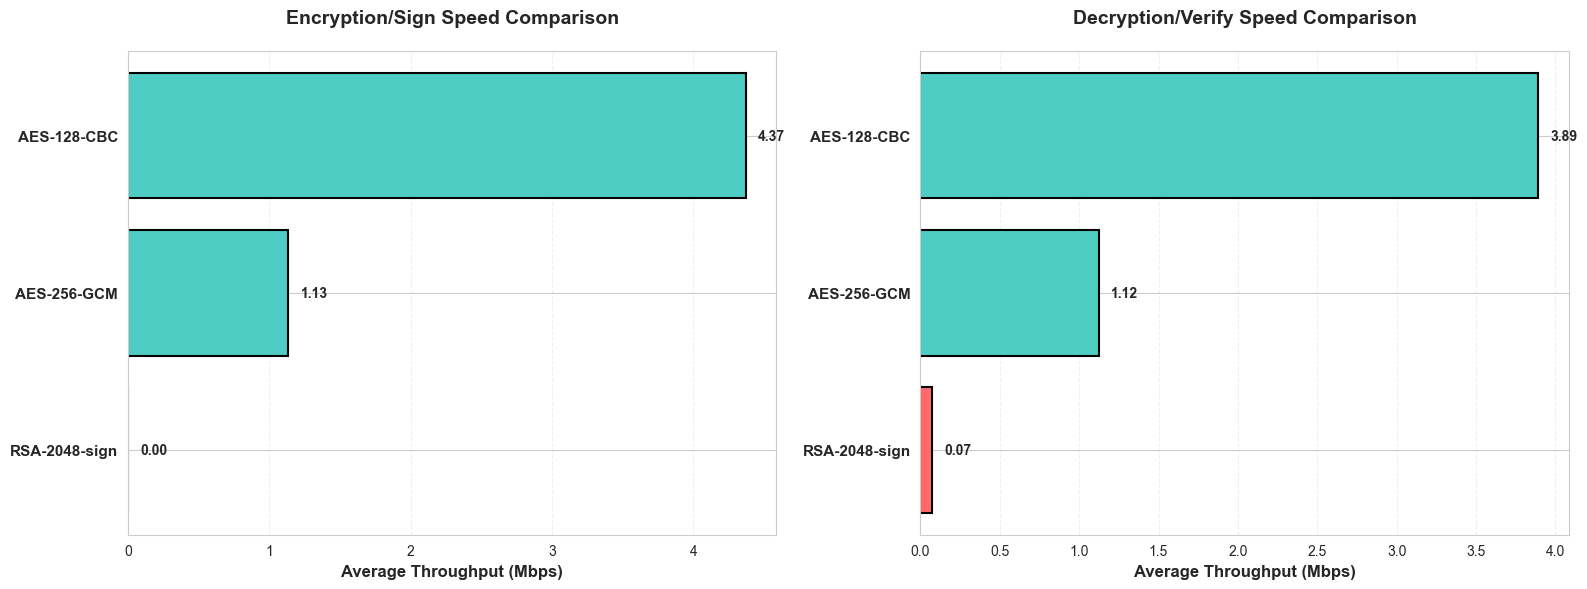

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average encryption speed by algorithm
avg_enc = df.groupby('alg')['enc_mbps'].mean().sort_values(ascending=True)
colors_enc = ['#FF6B6B' if x < 1 else '#4ECDC4' if x < 5 else '#95E1D3' for x in avg_enc.values]

axes[0].barh(range(len(avg_enc)), avg_enc.values, color=colors_enc, edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(avg_enc)))
axes[0].set_yticklabels(avg_enc.index, fontsize=11, fontweight='bold')
axes[0].set_xlabel('Average Throughput (Mbps)', fontsize=12, fontweight='bold')
axes[0].set_title('Encryption/Sign Speed Comparison', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(avg_enc.values):
    axes[0].text(v + max(avg_enc)*0.02, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=10)

# Average decryption speed by algorithm
avg_dec = df.groupby('alg')['dec_mbps'].mean().sort_values(ascending=True)
colors_dec = ['#FF6B6B' if x < 1 else '#4ECDC4' if x < 5 else '#95E1D3' for x in avg_dec.values]

axes[1].barh(range(len(avg_dec)), avg_dec.values, color=colors_dec, edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(avg_dec)))
axes[1].set_yticklabels(avg_dec.index, fontsize=11, fontweight='bold')
axes[1].set_xlabel('Average Throughput (Mbps)', fontsize=12, fontweight='bold')
axes[1].set_title('Decryption/Verify Speed Comparison', fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(avg_dec.values):
    axes[1].text(v + max(avg_dec)*0.02, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

##  Speed by Message Size (Grouped Bar Chart)

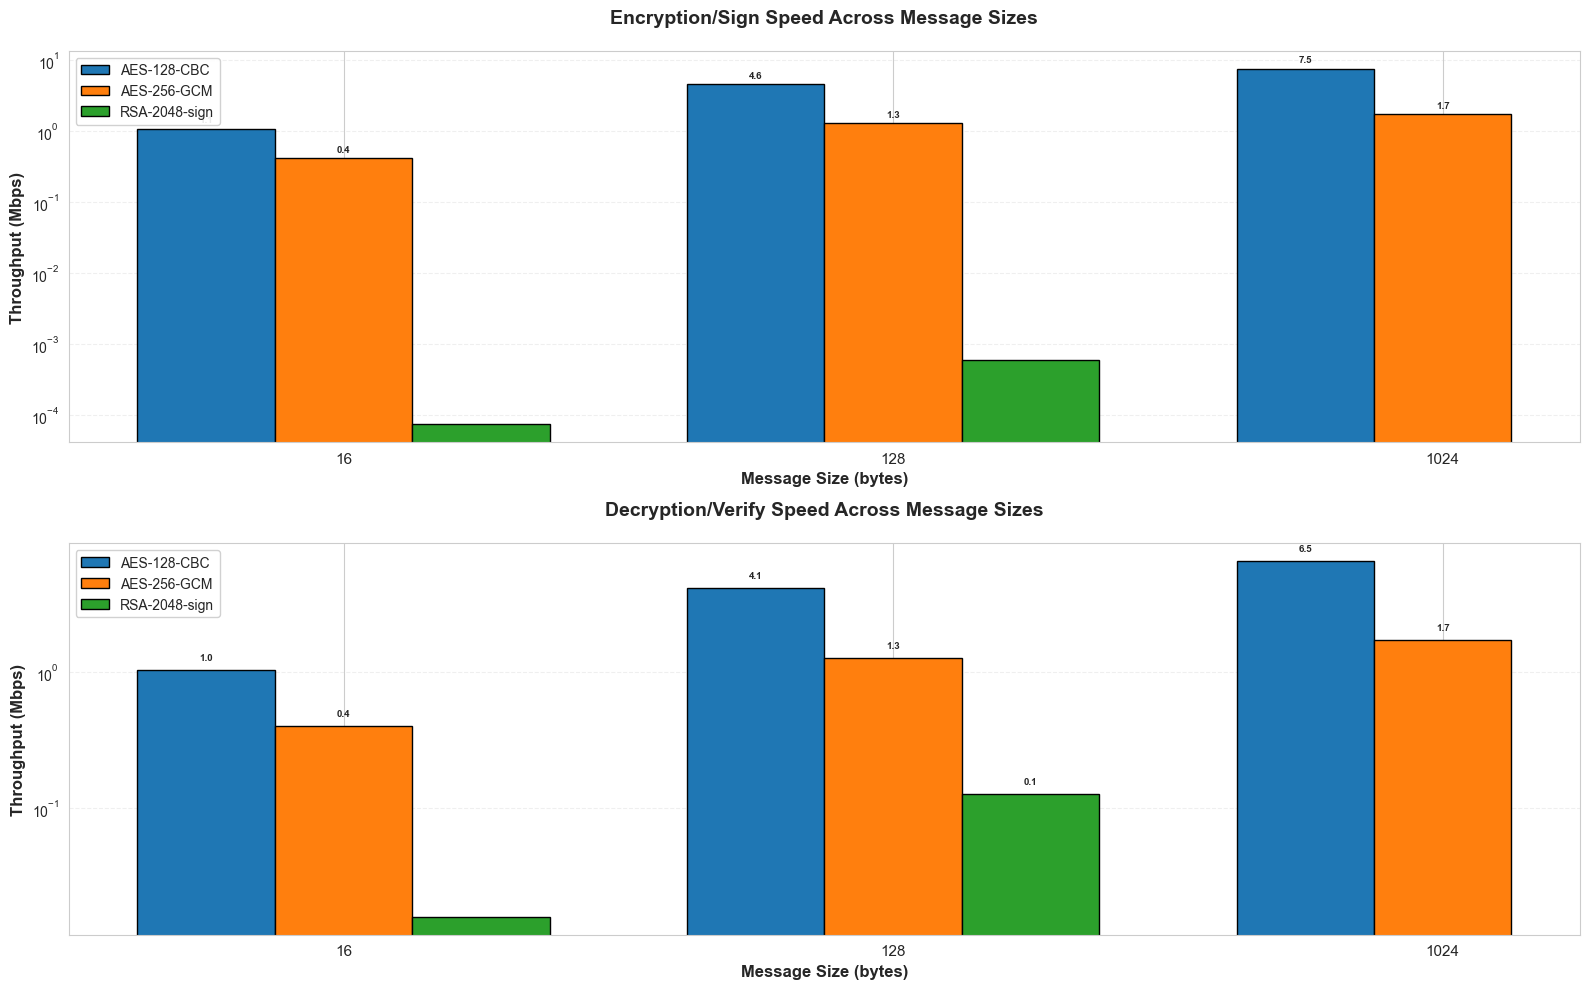

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

algorithms = df['alg'].unique()
sizes = sorted(df['size'].unique())
x = np.arange(len(sizes))
width = 0.25

# --- Encryption speeds ---
for i, alg in enumerate(algorithms):
    alg_data = df[df['alg'] == alg].sort_values('size')
    positions = [x[sizes.index(s)] for s in alg_data['size']]
    offset = width * (i - len(algorithms)/2 + 0.5)
    bars = axes[0].bar(np.array(positions) + offset, alg_data['enc_mbps'],
                       width, label=alg, edgecolor='black', linewidth=1)

axes[0].set_xlabel('Message Size (bytes)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Throughput (Mbps)', fontsize=12, fontweight='bold')
axes[0].set_title('Encryption/Sign Speed Across Message Sizes', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xticks(x)
axes[0].set_xticklabels(sizes, fontsize=11)
axes[0].legend(loc='upper left', framealpha=0.9, fontsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_yscale('log')

# Add value labels
for i, alg in enumerate(algorithms):
    alg_data = df[df['alg'] == alg].sort_values('size')
    positions = [x[sizes.index(s)] for s in alg_data['size']]
    offset = width * (i - len(algorithms)/2 + 0.5)
    for pos, val in zip(positions, alg_data['enc_mbps']):
        if val > 0.1:
            axes[0].text(pos + offset, val * 1.15,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# --- Decryption speeds ---
for i, alg in enumerate(algorithms):
    alg_data = df[df['alg'] == alg].sort_values('size')
    positions = [x[sizes.index(s)] for s in alg_data['size']]
    offset = width * (i - len(algorithms)/2 + 0.5)
    bars = axes[1].bar(np.array(positions) + offset, alg_data['dec_mbps'],
                       width, label=alg, edgecolor='black', linewidth=1)

axes[1].set_xlabel('Message Size (bytes)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Throughput (Mbps)', fontsize=12, fontweight='bold')
axes[1].set_title('Decryption/Verify Speed Across Message Sizes', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xticks(x)
axes[1].set_xticklabels(sizes, fontsize=11)
axes[1].legend(loc='upper left', framealpha=0.9, fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_yscale('log')

# Add value labels
for i, alg in enumerate(algorithms):
    alg_data = df[df['alg'] == alg].sort_values('size')
    positions = [x[sizes.index(s)] for s in alg_data['size']]
    offset = width * (i - len(algorithms)/2 + 0.5)
    for pos, val in zip(positions, alg_data['dec_mbps']):
        if val > 0.1:
            axes[1].text(pos + offset, val * 1.15,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()


##  Efficiency: Time per Operation

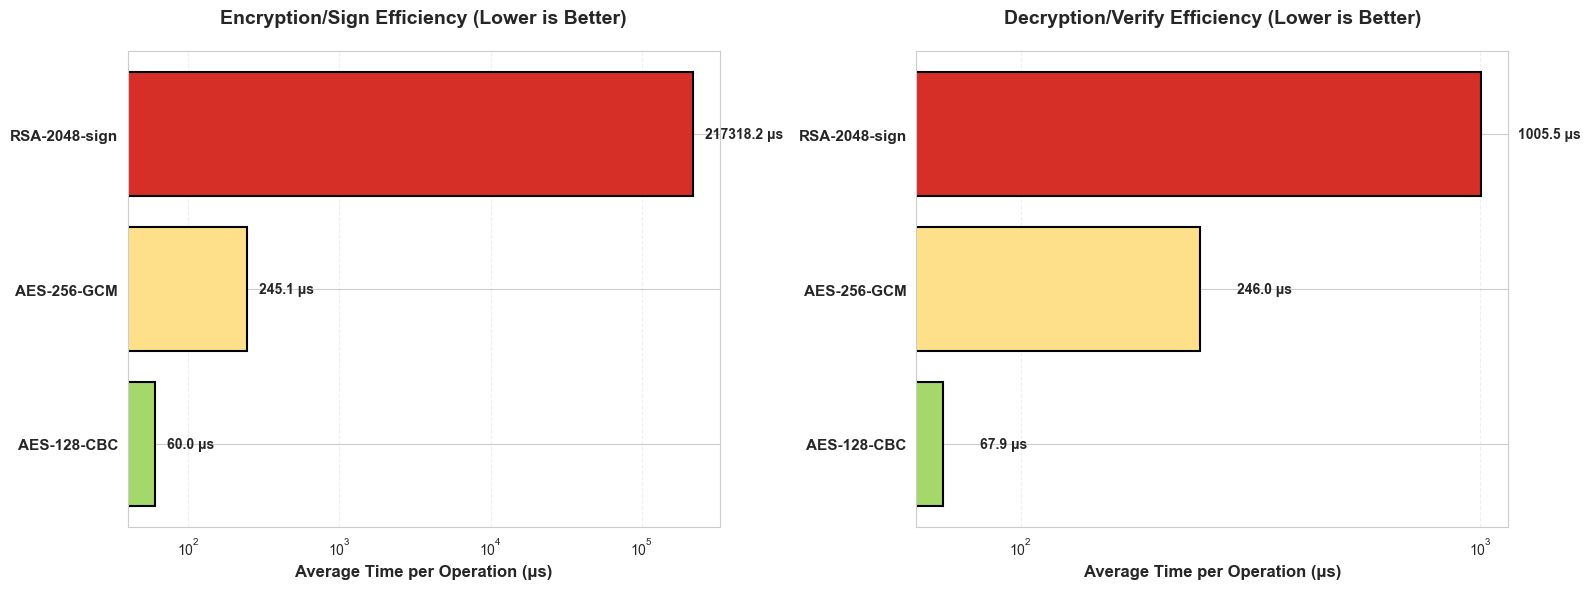

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average time per operation
avg_enc_time = df.groupby('alg')['enc_us_per_op'].mean().sort_values()
avg_dec_time = df.groupby('alg')['dec_us_per_op'].mean().sort_values()

# Encryption time
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(avg_enc_time)))
bars = axes[0].barh(range(len(avg_enc_time)), avg_enc_time.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(avg_enc_time)))
axes[0].set_yticklabels(avg_enc_time.index, fontsize=11, fontweight='bold')
axes[0].set_xlabel('Average Time per Operation (μs)', fontsize=12, fontweight='bold')
axes[0].set_title('Encryption/Sign Efficiency (Lower is Better)', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].set_xscale('log')

for i, v in enumerate(avg_enc_time.values):
    axes[0].text(v * 1.2, i, f'{v:.1f} μs', va='center', fontweight='bold', fontsize=10)

# Decryption time
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(avg_dec_time)))
bars = axes[1].barh(range(len(avg_dec_time)), avg_dec_time.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(avg_dec_time)))
axes[1].set_yticklabels(avg_dec_time.index, fontsize=11, fontweight='bold')
axes[1].set_xlabel('Average Time per Operation (μs)', fontsize=12, fontweight='bold')
axes[1].set_title('Decryption/Verify Efficiency (Lower is Better)', fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].set_xscale('log')

for i, v in enumerate(avg_dec_time.values):
    axes[1].text(v * 1.2, i, f'{v:.1f} μs', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Speed Heatmaps (All Algorithms × All Message Sizes)

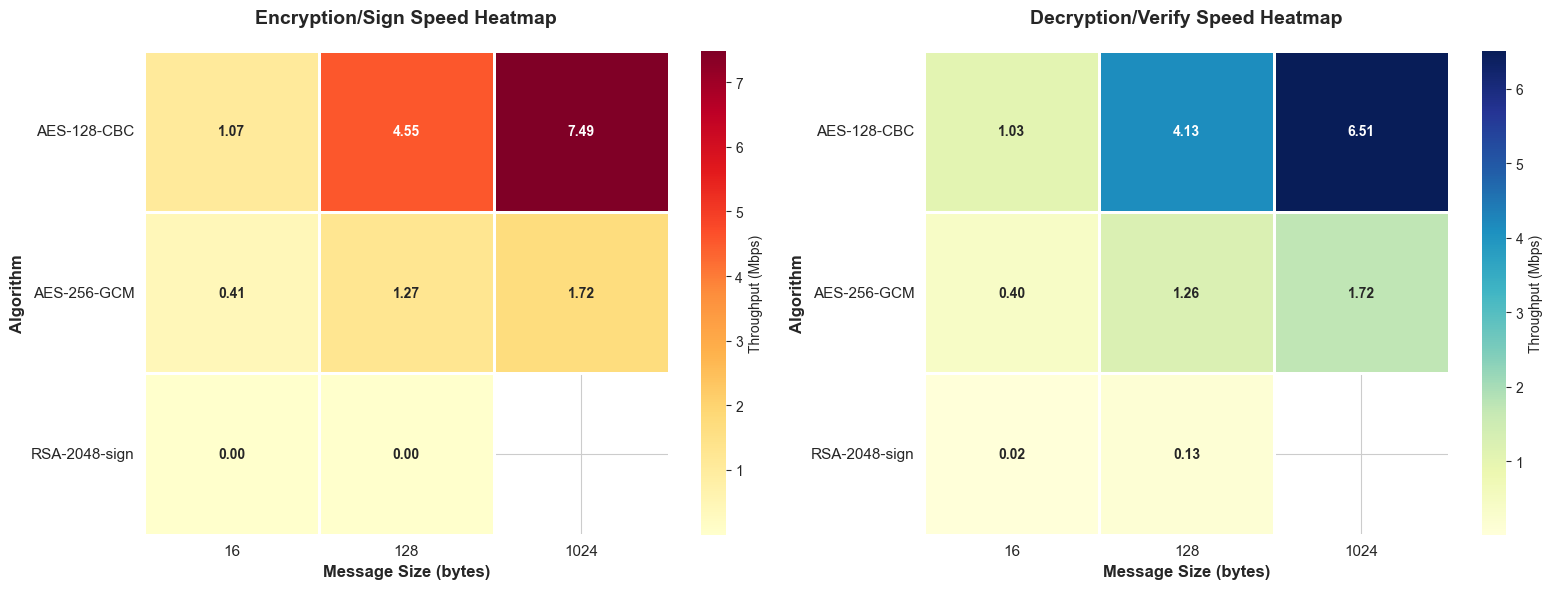

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Encryption heatmap
enc_pivot = df.pivot_table(index='alg', columns='size', values='enc_mbps', aggfunc='mean')
sns.heatmap(enc_pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Throughput (Mbps)'}, linewidths=1, linecolor='white',
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
axes[0].set_title('Encryption/Sign Speed Heatmap', fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Message Size (bytes)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Algorithm', fontsize=12, fontweight='bold')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, fontsize=11)

# Decryption heatmap
dec_pivot = df.pivot_table(index='alg', columns='size', values='dec_mbps', aggfunc='mean')
sns.heatmap(dec_pivot, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1],
            cbar_kws={'label': 'Throughput (Mbps)'}, linewidths=1, linecolor='white',
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Decryption/Verify Speed Heatmap', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Message Size (bytes)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Algorithm', fontsize=12, fontweight='bold')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

## Memory Efficiency Comparison

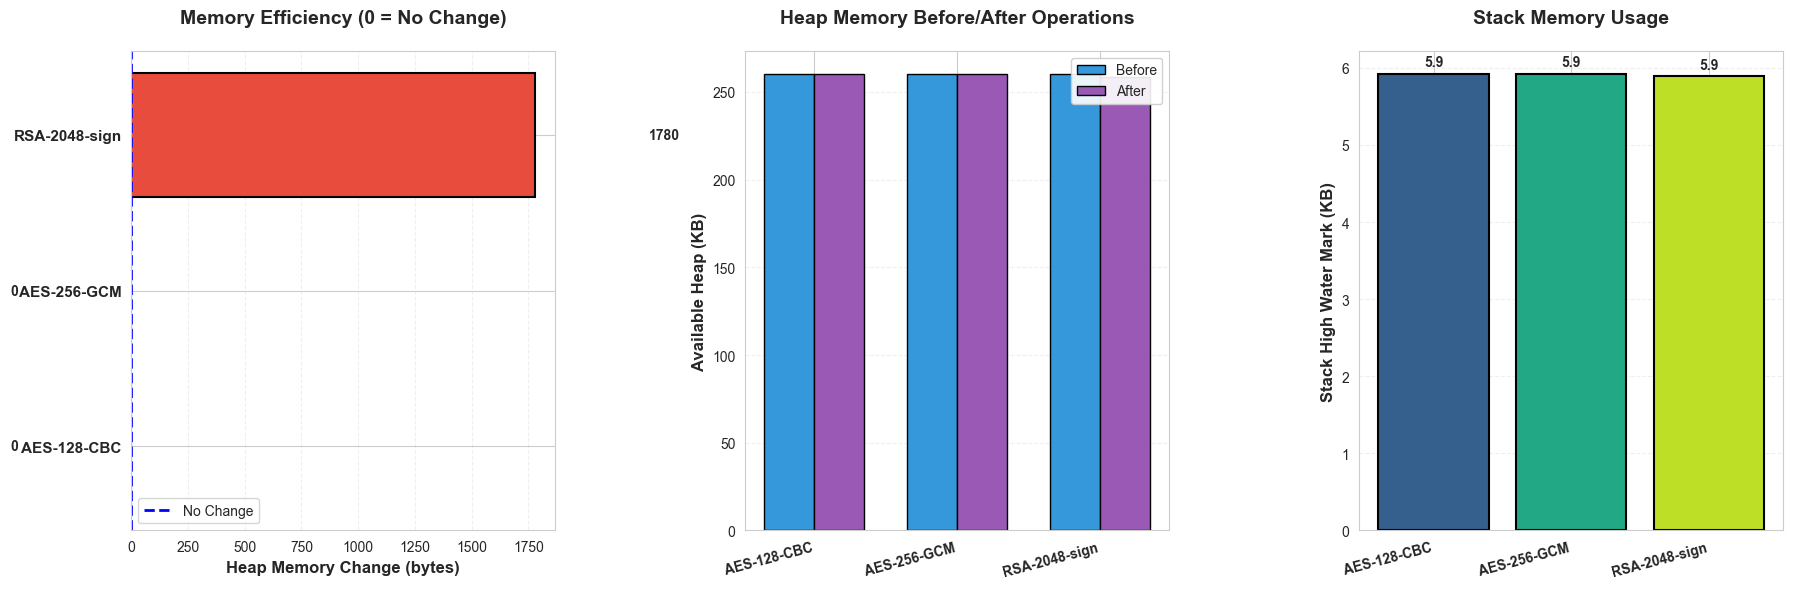

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Average heap usage
heap_usage = df.groupby('alg')['heap_used'].mean().sort_values()
colors = ['#2ECC71' if x <= 0 else '#E74C3C' for x in heap_usage.values]

axes[0].barh(range(len(heap_usage)), heap_usage.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(heap_usage)))
axes[0].set_yticklabels(heap_usage.index, fontsize=11, fontweight='bold')
axes[0].set_xlabel('Heap Memory Change (bytes)', fontsize=12, fontweight='bold')
axes[0].set_title('Memory Efficiency (0 = No Change)', fontsize=14, fontweight='bold', pad=20)
axes[0].axvline(x=0, color='blue', linestyle='--', linewidth=2, label='No Change')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].legend()

for i, v in enumerate(heap_usage.values):
    axes[0].text(v + (500 if v > 0 else -500), i, f'{int(v)}', va='center', 
                 ha='left' if v > 0 else 'right', fontweight='bold', fontsize=10)

# Average heap available
heap_before = df.groupby('alg')['heap_before'].mean().sort_values(ascending=False)
heap_after = df.groupby('alg')['heap_after'].mean().reindex(heap_before.index)

x_pos = np.arange(len(heap_before))
width = 0.35

axes[1].bar(x_pos - width/2, heap_before/1024, width, label='Before', color='#3498DB', edgecolor='black')
axes[1].bar(x_pos + width/2, heap_after/1024, width, label='After', color='#9B59B6', edgecolor='black')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(heap_before.index, rotation=15, ha='right', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Available Heap (KB)', fontsize=12, fontweight='bold')
axes[1].set_title('Heap Memory Before/After Operations', fontsize=14, fontweight='bold', pad=20)
axes[1].legend(framealpha=0.9)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Stack usage
stack_usage = df.groupby('alg')['stack_hwm_after'].mean().sort_values(ascending=False)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(stack_usage)))

axes[2].bar(range(len(stack_usage)), stack_usage.values/1024, color=colors, edgecolor='black', linewidth=1.5)
axes[2].set_xticks(range(len(stack_usage)))
axes[2].set_xticklabels(stack_usage.index, rotation=15, ha='right', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Stack High Water Mark (KB)', fontsize=12, fontweight='bold')
axes[2].set_title('Stack Memory Usage', fontsize=14, fontweight='bold', pad=20)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')

for i, v in enumerate(stack_usage.values):
    axes[2].text(i, v/1024 + 0.1, f'{v/1024:.1f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Radar Chart: Multi-dimensional Performance Comparison

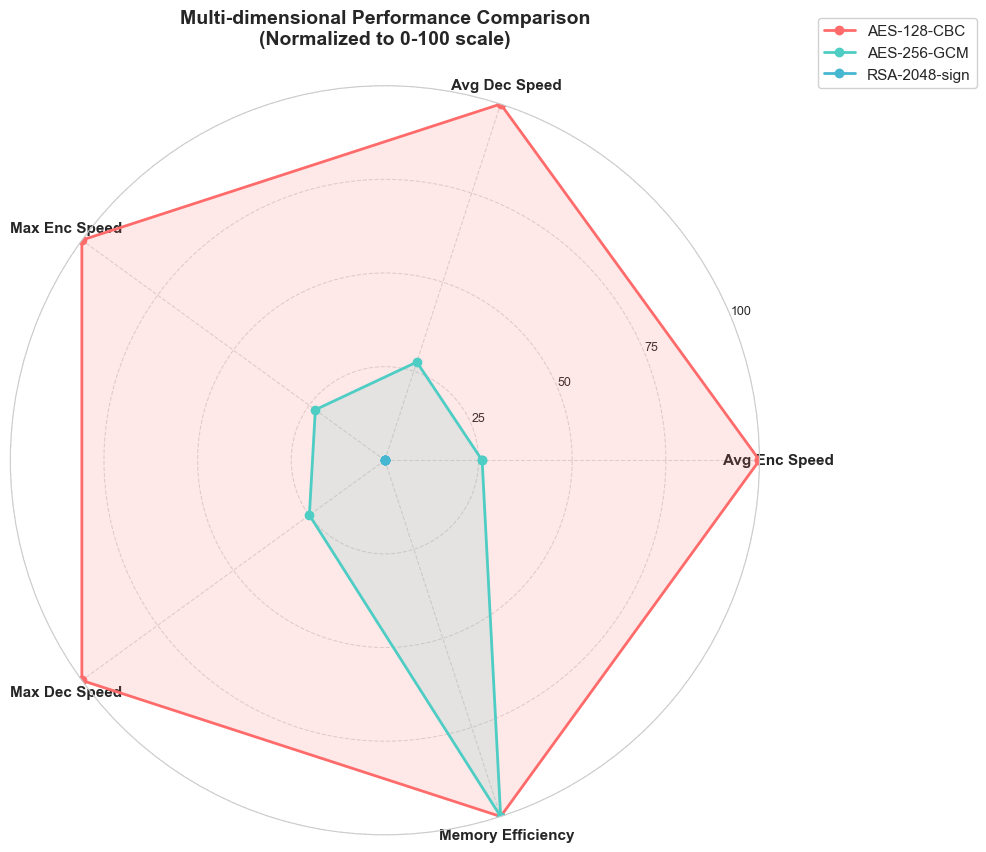

In [7]:
from math import pi

# Prepare data for radar chart - normalize metrics to 0-1 scale
algorithms = df['alg'].unique()

# Metrics to compare (higher is better for all)
metrics_data = []
for alg in algorithms:
    alg_df = df[df['alg'] == alg]
    metrics_data.append({
        'Algorithm': alg,
        'Avg Enc Speed': alg_df['enc_mbps'].mean(),
        'Avg Dec Speed': alg_df['dec_mbps'].mean(),
        'Max Enc Speed': alg_df['enc_mbps'].max(),
        'Max Dec Speed': alg_df['dec_mbps'].max(),
        'Memory Efficiency': 10000 / (abs(alg_df['heap_used'].mean()) + 1),  # Inverse of heap usage
    })

metrics_df = pd.DataFrame(metrics_data).set_index('Algorithm')

# Normalize to 0-100 scale
metrics_norm = (metrics_df - metrics_df.min()) / (metrics_df.max() - metrics_df.min()) * 100

# Create radar chart
categories = list(metrics_norm.columns)
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, alg in enumerate(algorithms):
    values = metrics_norm.loc[alg].tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=alg, color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.15, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25', '50', '75', '100'], fontsize=9)
ax.set_title('Multi-dimensional Performance Comparison\n(Normalized to 0-100 scale)', 
             fontsize=14, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Performance Summary Dashboard

C:\Users\Jedi\AppData\Local\Temp\ipykernel_9532\3267902792.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_total_speed = df.groupby('alg').apply(
C:\Users\Jedi\AppData\Local\Temp\ipykernel_9532\3267902792.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(heap_impact.index, rotation=25, ha='right', fontsize=9, fontweight='bold')
C:\Users\Jedi\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Jedi\AppData\Roaming\Python\Python311\site-packages\I

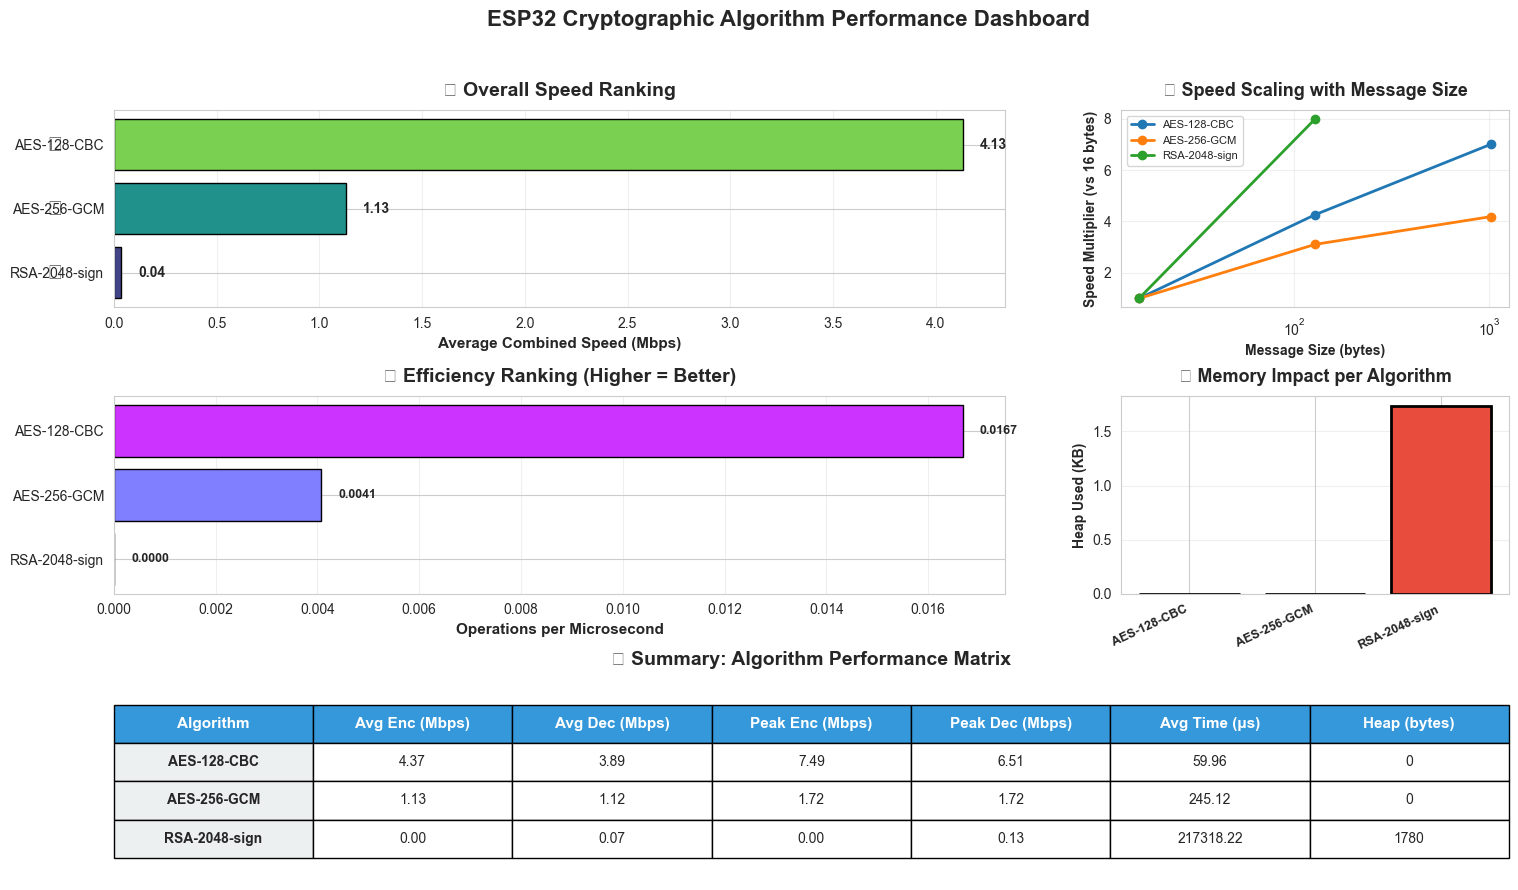

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

required_cols = ['alg', 'size', 'enc_mbps', 'dec_mbps', 'enc_us_per_op', 'heap_used']
df = df[[c for c in required_cols if c in df.columns]].dropna()
for col in ['enc_mbps', 'dec_mbps', 'enc_us_per_op', 'heap_used']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

algorithms = df['alg'].unique()

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.3)

# 1️ Overall Speed Ranking
ax1 = fig.add_subplot(gs[0, :2])
avg_total_speed = df.groupby('alg').apply(
    lambda x: (x['enc_mbps'].mean() + x['dec_mbps'].mean()) / 2
).sort_values()

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(avg_total_speed)))
bars = ax1.barh(avg_total_speed.index, avg_total_speed.values, color=colors, edgecolor='black')

ax1.set_xlabel('Average Combined Speed (Mbps)', fontsize=11, fontweight='bold')
ax1.set_title('🏆 Overall Speed Ranking', fontsize=14, fontweight='bold', pad=10)
ax1.grid(axis='x', alpha=0.3)

for i, v in enumerate(avg_total_speed.values):
    ax1.text(v + max(avg_total_speed)*0.02, i, f'{v:.2f}', va='center', fontweight='bold')
    if i == len(avg_total_speed) - 1:
        ax1.text(-max(avg_total_speed)*0.08, i, '🥇', va='center', fontsize=16)
    elif i == len(avg_total_speed) - 2:
        ax1.text(-max(avg_total_speed)*0.08, i, '🥈', va='center', fontsize=16)
    elif i == len(avg_total_speed) - 3:
        ax1.text(-max(avg_total_speed)*0.08, i, '🥉', va='center', fontsize=16)

# 2️ Speed Scaling by Message Size
ax2 = fig.add_subplot(gs[0, 2])
for alg in algorithms:
    alg_data = df[df['alg'] == alg].sort_values('size')
    if len(alg_data) > 1:
        base_speed = max(alg_data['enc_mbps'].values[0], 1e-9)
        speedup = alg_data['enc_mbps'].values / base_speed
        ax2.plot(alg_data['size'], speedup, marker='o', linewidth=2, label=alg)

ax2.set_xlabel('Message Size (bytes)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Speed Multiplier (vs 16 bytes)', fontsize=10, fontweight='bold')
ax2.set_title('📈 Speed Scaling with Message Size', fontsize=13, fontweight='bold', pad=10)
ax2.set_xscale('log')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 3️ Efficiency Ranking
ax3 = fig.add_subplot(gs[1, :2])
avg_efficiency = (1 / df.groupby('alg')['enc_us_per_op'].mean()).replace([np.inf, -np.inf], 0).sort_values()
colors_eff = plt.cm.cool(np.linspace(0.2, 0.8, len(avg_efficiency)))
bars = ax3.barh(avg_efficiency.index, avg_efficiency.values, color=colors_eff, edgecolor='black')

ax3.set_xlabel('Operations per Microsecond', fontsize=11, fontweight='bold')
ax3.set_title('⚡ Efficiency Ranking (Higher = Better)', fontsize=14, fontweight='bold', pad=10)
ax3.grid(axis='x', alpha=0.3)

for i, v in enumerate(avg_efficiency.values):
    ax3.text(v + max(avg_efficiency)*0.02, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)

# 4️ Memory Usage Impact
ax4 = fig.add_subplot(gs[1, 2])
heap_impact = df.groupby('alg')['heap_used'].mean().abs()
colors_mem = ['#2ECC71' if val <= heap_impact.median() else '#E74C3C' for val in heap_impact.values]
ax4.bar(heap_impact.index, heap_impact.values/1024, color=colors_mem, edgecolor='black', linewidth=2)

ax4.set_ylabel('Heap Used (KB)', fontsize=10, fontweight='bold')
ax4.set_title('💾 Memory Impact per Algorithm', fontsize=13, fontweight='bold', pad=10)
ax4.set_xticklabels(heap_impact.index, rotation=25, ha='right', fontsize=9, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# 5️ Performance Summary Table
ax5 = fig.add_subplot(gs[2, :])
summary_data = []
for alg in algorithms:
    alg_df = df[df['alg'] == alg]
    summary_data.append([
        alg,
        f"{alg_df['enc_mbps'].mean():.2f}",
        f"{alg_df['dec_mbps'].mean():.2f}",
        f"{alg_df['enc_mbps'].max():.2f}",
        f"{alg_df['dec_mbps'].max():.2f}",
        f"{alg_df['enc_us_per_op'].mean():.2f}",
        f"{int(abs(alg_df['heap_used'].mean()))}"
    ])

summary_df = pd.DataFrame(summary_data,
                          columns=['Algorithm', 'Avg Enc (Mbps)', 'Avg Dec (Mbps)',
                                   'Peak Enc (Mbps)', 'Peak Dec (Mbps)',
                                   'Avg Time (μs)', 'Heap (bytes)'])

ax5.axis('tight')
ax5.axis('off')

table = ax5.table(cellText=summary_df.values,
                  colLabels=summary_df.columns,
                  cellLoc='center', loc='center',
                  colColours=['#3498DB']*len(summary_df.columns))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.3)

# Header Styling
for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#3498DB')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=11)

# Row Styling
for i in range(len(summary_df)):
    table[(i+1, 0)].set_text_props(weight='bold')
    table[(i+1, 0)].set_facecolor('#ECF0F1')

ax5.set_title('📊 Summary: Algorithm Performance Matrix', fontsize=14, fontweight='bold', pad=20, y=0.95)

# Main Title
plt.suptitle('ESP32 Cryptographic Algorithm Performance Dashboard',
             fontsize=16, fontweight='bold', y=0.98)
plt.show()
